## Project: Predicting Heart Failure Death Events Using Clinical Data

### Introduction
Cardiovascular diseases remain a leading global cause of death. Timely prediction of death events from clinical indicators can significantly aid healthcare professionals in managing patient outcomes. This project aims to leverage machine learning to predict mortality among heart failure patients based on clinical attributes.

### Dataset Description

The dataset contains 299 observations and 13 clinical features sourced publicly from the Heart Failure Clinical Records Dataset. Key variables include patient age, ejection fraction, serum creatinine, serum sodium, and follow-up time, among others.

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

In [2]:
# Load Dataset
data = pd.read_csv('heart_failure_clinical_records_dataset.csv', na_values=['?'])
data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
data.shape

(299, 13)

In [4]:
data.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


### Exploratory Data Analysis (EDA)

The EDA revealed several insights:

Most patients range in age from 40 to 70, with a slightly right-skewed distribution.

Clinical markers such as creatinine phosphokinase and serum creatinine show heavily skewed distributions, indicating a few significantly elevated clinical values.

Ejection fraction, a measure of heart pumping effectiveness, shows moderate symmetry centered around 30-40%.

Boxplots clearly indicate differences in critical variables (time, serum creatinine, ejection fraction, age, serum sodium) between surviving and non-surviving groups.

In [5]:
data.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

We can clearly see that there are no missing data =, so we proceed with our analysis

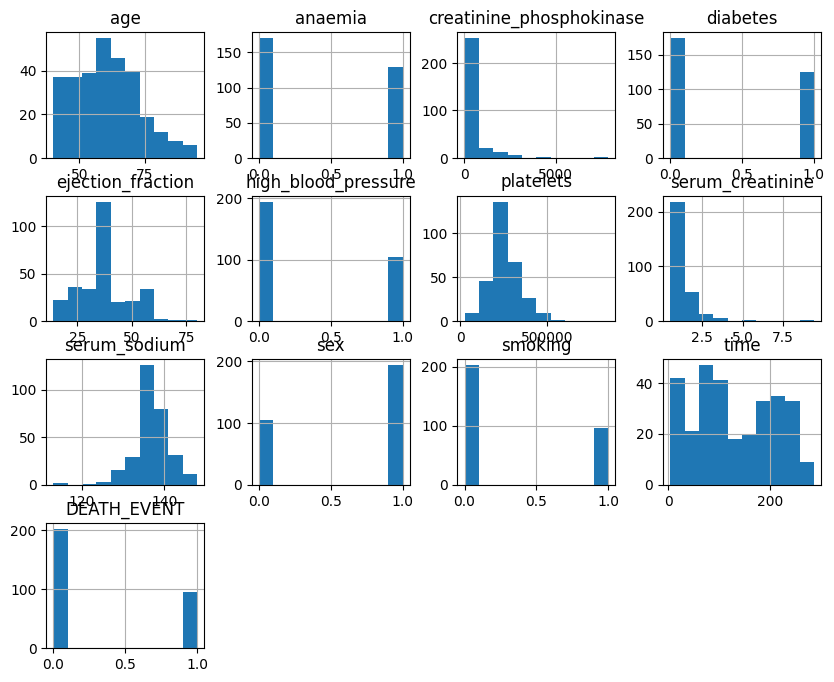

In [6]:
data.hist(figsize=(10, 8))
plt.show()

1. **age:** The distribution is slightly right-skewed, indicating most individuals in the dataset are aged between 40 and 70 years.
2. **anaemia:** The plot shows a higher frequency of individuals without anaemia (0) compared to those with anaemia (1).
3. **creatinine_phosphokinase:** A highly right-skewed distribution, suggesting most individuals have low levels of creatinine phosphokinase with some extreme high values.
4. **diabetes:** More individuals do not have diabetes (0), though a substantial number also have diabetes (1).
5. **ejection_fraction:** A roughly symmetrical distribution centered around 30-40%, suggesting most individuals have moderately reduced heart-pumping capability.
6. **high_blood_pressure:** More individuals do not have high blood pressure (0), but there is a notable minority with high blood pressure (1).
7. **platelets:** Distribution is relatively symmetrical with a slight right skew, showing most individuals have normal platelet counts but some higher outliers.
8. **serum_creatinine:** Heavily right-skewed, indicating most individuals have normal creatinine levels but a few have significantly elevated values.
9. **serum_sodium:** Slightly left-skewed distribution with the majority of serum sodium levels concentrated around normal physiological values (around 135-140).
10. **sex:** Male individuals (1) are slightly more represented than females (0) in the dataset.
11. **smoking:** A higher frequency of non-smokers (0) compared to smokers (1).
12. **time:** Relatively uniform distribution with a slight drop-off at higher values, showing follow-up time durations are evenly spread.
13. **DEATH_EVENT:** Fewer individuals experienced death (1), with most individuals surviving (0).

### Correlation Matrix

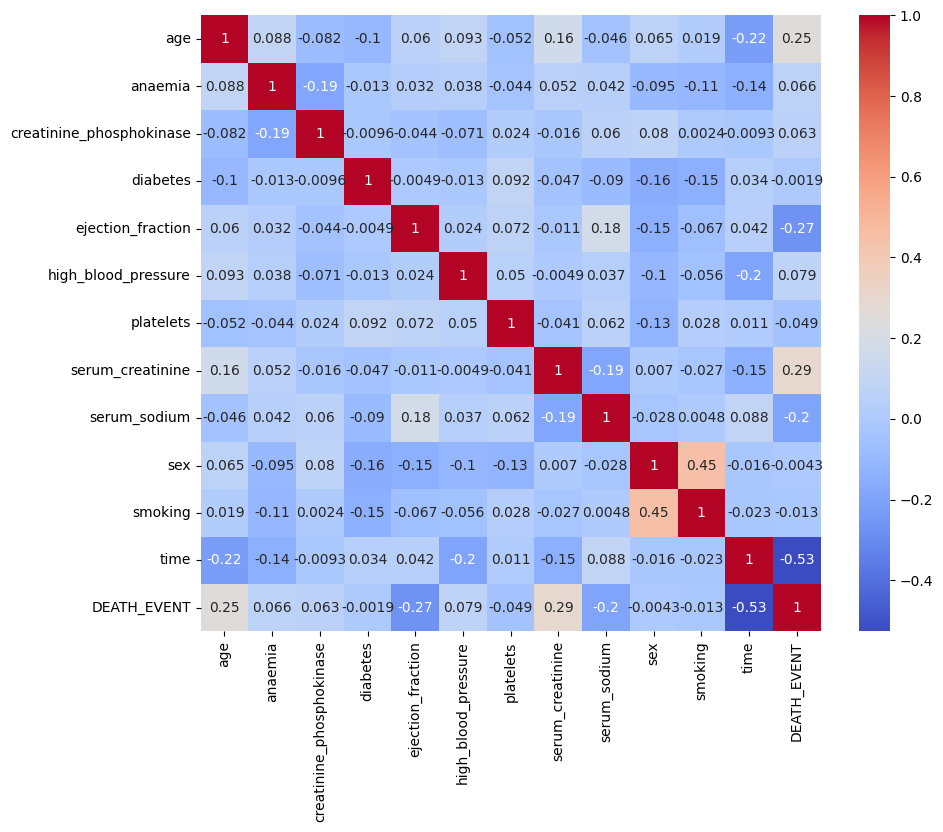

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

Based on this correlation matrix, the most important features to focus on for analysis (those showing relatively stronger correlation with **DEATH_EVENT**) are:

1. **time** (−0.53): Strong negative correlation, indicating shorter follow-up time is associated with a higher likelihood of death.
2. **serum_creatinine** (0.29): Moderate positive correlation, suggesting higher serum creatinine levels are associated with an increased risk of death.
3. **ejection_fraction** (−0.27): Moderate negative correlation, indicating lower ejection fractions relate to higher risk of death.
4. **age** (0.25): Moderate positive correlation, indicating older age increases death risk.
5. **serum_sodium** (−0.20): Weak negative correlation, suggesting lower serum sodium levels are somewhat associated with higher death risk.

**Flagging `time` here before going further:** it's the strongest correlate in the whole dataset, but it's also not a real clinical predictor. `time` is the patient's follow-up duration - how long they were tracked before the study recorded an outcome. Patients who died were, by definition, more likely to have a shorter follow-up window. That's a look-ahead problem, not a clinical signal: at the moment you'd actually want a prediction, you don't know in advance how many days of follow-up a patient will have. Worth testing directly rather than just asserting it - see the check right after feature selection below.

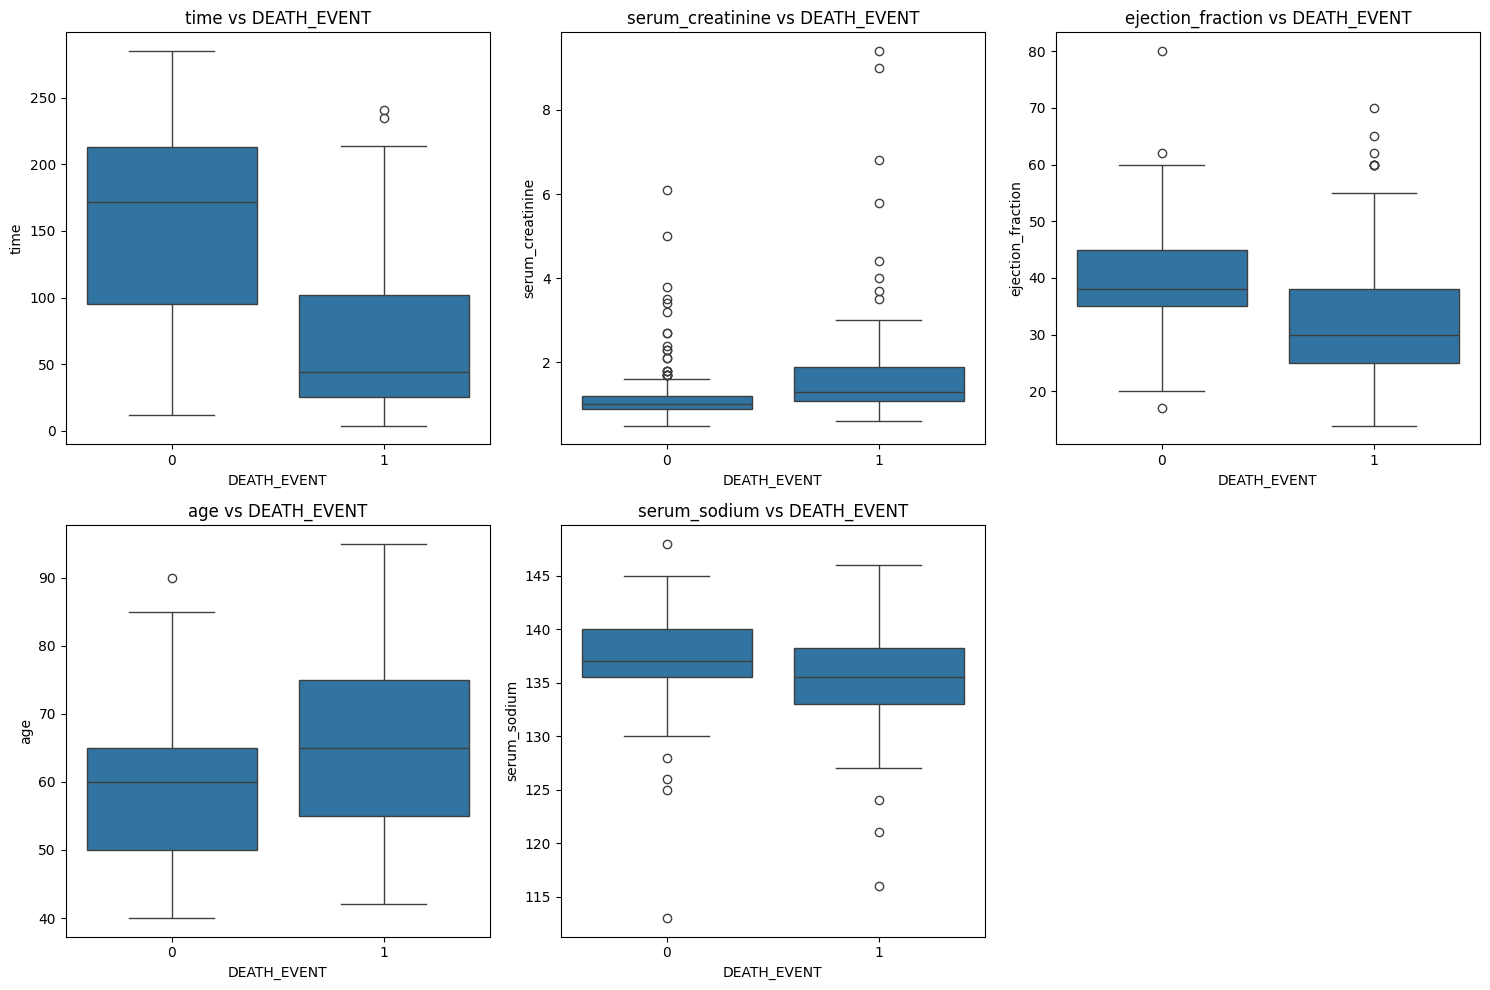

In [8]:
# Boxplots for numerical features
plt.figure(figsize=(15, 10))
for i, feature in enumerate(['time', 'serum_creatinine', 'ejection_fraction', 'age', 'serum_sodium']):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='DEATH_EVENT', y=feature, data=data)
    plt.title(f'{feature} vs DEATH_EVENT')
plt.tight_layout()
plt.show()

Interpretation from the boxplots:

1. **Time vs DEATH_EVENT**:  
   Individuals who died (DEATH_EVENT=1) generally have shorter follow-up times compared to survivors, indicating that shorter durations strongly associate with death.

2. **Serum_creatinine vs DEATH_EVENT**:  
   Serum creatinine levels tend to be higher among individuals who died, signifying that elevated creatinine is indicative of higher mortality risk.

3. **Ejection_fraction vs DEATH_EVENT**:  
   Lower ejection fraction values clearly correspond to death events, suggesting reduced heart function significantly increases mortality risk.

4. **Age vs DEATH_EVENT**:  
   Individuals who died are generally older, indicating age as a notable factor influencing mortality.

5. **Serum_sodium vs DEATH_EVENT**:  
   Slightly lower serum sodium levels are associated with death, although the difference between groups is smaller, indicating a relatively weaker relationship with mortality.


### Feature Selection

The correlation analysis above points to five features: `time`, `serum_creatinine`, `ejection_fraction`, `age`, and `serum_sodium`.

`time` gets dropped from the model used going forward, for the reason flagged above - it's not available at prediction time in any realistic use of this model, so training on it produces a number that looks good on this dataset but doesn't reflect what the model could actually do in practice. The section right below tests that claim directly instead of just asserting it.

The four features used for the rest of this notebook are **serum_creatinine, ejection_fraction, age, and serum_sodium**.

### Checking the `time` Leakage Claim

Before moving on, here's a direct comparison: the same Random Forest, cross-validated, with `time` included vs. excluded. If `time` were just a normal strong predictor, removing it should cost some accuracy but the model should stay stable. If it's leakage, the effect should be bigger and messier than that.

In [9]:
from sklearn.ensemble import RandomForestClassifier as _RFCheck

y_check = data['DEATH_EVENT']

with_time = ['time', 'serum_creatinine', 'ejection_fraction', 'age', 'serum_sodium']
without_time = ['serum_creatinine', 'ejection_fraction', 'age', 'serum_sodium']

cv_with = cross_val_score(_RFCheck(random_state=42), data[with_time], y_check, cv=StratifiedKFold(5, shuffle=True, random_state=42))
cv_without = cross_val_score(_RFCheck(random_state=42), data[without_time], y_check, cv=StratifiedKFold(5, shuffle=True, random_state=42))

print("5-fold CV accuracy WITH time:    %.3f +/- %.3f" % (cv_with.mean(), cv_with.std()))
print("5-fold CV accuracy WITHOUT time: %.3f +/- %.3f" % (cv_without.mean(), cv_without.std()))

5-fold CV accuracy WITH time:    0.809 +/- 0.039
5-fold CV accuracy WITHOUT time: 0.716 +/- 0.068


With proper stratified cross-validation, `time` actually makes the score both higher and more stable (0.809 +/- 0.039 vs. 0.716 +/- 0.068 without it) - which is a more important lesson than a clean "leakage makes things unstable" story would have been. It doesn't. Leakage can just make a model look straightforwardly better, with no statistical red flag in the cross-validation numbers themselves. The only way to catch it here is by reasoning about the feature, not the metrics: `time` is not known at the moment you'd want a prediction, so no matter how good or stable the CV score looks, it isn't a valid predictor for a model meant to be used going forward. `time` is excluded from every model from here on, and the numbers that follow are honestly worse than they'd be with it - that's expected, and it's the right tradeoff.

### Data Preprocessing

Features are standardized with `StandardScaler`, fit on the training set only and then applied to the test set. Fitting the scaler before splitting (on the full dataset) would leak test-set statistics into training - a subtle mistake, but worth doing correctly since it's a one-line fix.

### Train-Test Split

In [10]:
features = ['serum_creatinine', 'ejection_fraction', 'age', 'serum_sodium']
target = 'DEATH_EVENT'

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit the scaler on the training data only, then apply it to both splits.
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Modeling & Evaluation

Two algorithms were applied, both with `class_weight="balanced"` since survivors outnumber deaths roughly 2:1 in this dataset (68% / 32%) and an unweighted model tends to under-predict the minority class:

- **Logistic Regression**: chosen for interpretability and simplicity.
- **Random Forest**: tuned with `GridSearchCV` over tree depth, leaf size, and estimator count, using 5-fold cross-validated ROC-AUC rather than a single train/test split.

ROC-AUC is reported alongside accuracy/precision/recall - with a 68/32 class split, accuracy alone can look fine while still missing most of the minority class, which is exactly what happened in the first pass of this notebook.

In [11]:
logreg = LogisticRegression(class_weight="balanced", random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

lr_auc = roc_auc_score(y_test, logreg.predict_proba(X_test_scaled)[:, 1])
print(f"Test ROC-AUC: {lr_auc:.3f}")

lr_cv_auc = cross_val_score(
    LogisticRegression(class_weight="balanced", random_state=42),
    scaler.transform(X), y, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring="roc_auc"
)
print(f"5-fold CV ROC-AUC: {lr_cv_auc.mean():.3f} +/- {lr_cv_auc.std():.3f}")

              precision    recall  f1-score   support

           0       0.86      0.78      0.82        41
           1       0.61      0.74      0.67        19

    accuracy                           0.77        60
   macro avg       0.74      0.76      0.74        60
weighted avg       0.78      0.77      0.77        60

[[32  9]
 [ 5 14]]
Test ROC-AUC: 0.791
5-fold CV ROC-AUC: 0.780 +/- 0.069


In [12]:
param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [3, 5, 8, None],
    "min_samples_leaf": [1, 3, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1,
)
grid_search.fit(X_train_scaled, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV ROC-AUC: {grid_search.best_score_:.3f}")

rf_model = grid_search.best_estimator_
y_pred_rf = rf_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf))

rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])
print(f"Test ROC-AUC: {rf_auc:.3f}")

importance = rf_model.feature_importances_
for feature, imp in sorted(zip(features, importance), key=lambda x: -x[1]):
    print(f"{feature}: {imp:.3f}")

Best params: {'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV ROC-AUC: 0.800
              precision    recall  f1-score   support

           0       0.82      0.80      0.81        41
           1       0.60      0.63      0.62        19

    accuracy                           0.75        60
   macro avg       0.71      0.72      0.72        60
weighted avg       0.75      0.75      0.75        60

Test ROC-AUC: 0.802
serum_creatinine: 0.437
ejection_fraction: 0.335
age: 0.136
serum_sodium: 0.091


The tuned Random Forest (`max_depth=3, min_samples_leaf=1, n_estimators=100`, chosen by 5-fold CV ROC-AUC) leans heavily on `serum_creatinine` (0.437) and `ejection_fraction` (0.335), with `age` (0.136) and `serum_sodium` (0.091) contributing less. That ordering matches the correlation analysis from earlier - a reasonable sanity check that the model isn't picking up on anything the EDA didn't already suggest, now that `time` is out of the picture.

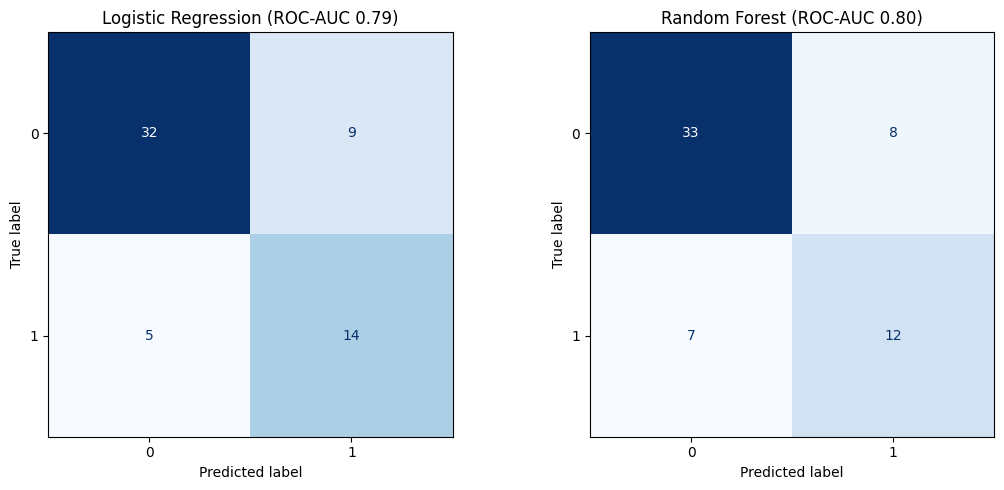

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Logistic Regression (ROC-AUC {lr_auc:.2f})")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title(f"Random Forest (ROC-AUC {rf_auc:.2f})")
plt.tight_layout()
plt.show()

### Results

With `time` removed, class weighting applied, and the Random Forest properly tuned, both models land around **ROC-AUC 0.79-0.80** (Logistic Regression: 0.791 test / 0.780 +/- 0.069 CV; Random Forest: 0.802 test / 0.800 CV). Accuracy alone is a similar 75-77% for both.

The more useful comparison is recall on the death class, since that's the number that matters most for a health-outcomes tool: Logistic Regression catches 74% of actual deaths (up from 52% in the original unweighted version of this notebook) at the cost of dropping precision on that class to 61% (from 93%). Random Forest is more balanced - 63% recall, 60% precision on deaths. Neither is dramatically better than the other; Logistic Regression is the one to lean on if missing an at-risk patient is the worse failure mode, which is the usual assumption in a screening context.

The honest summary: this version is worse-looking than the original 78%-accuracy, `time`-included notebook, and that's the point. The original number was inflated by a feature that wouldn't exist at prediction time. What's here now is lower, but it's a number this model could actually be expected to hit in practice.

### Limitations

This is a small dataset (299 patients, one clinical study) and hasn't been externally validated on a different patient population - performance here shouldn't be assumed to generalize. `time` was excluded because it isn't available at prediction time in real use, which is the right call for a deployable model but does mean this notebook is intentionally reporting worse-looking numbers than a leaky version would. Precision on the death class is still moderate (see the classification report above), meaning a real deployment would need a human clinician in the loop reviewing flagged cases, not an automated decision. This project is a modeling exercise, not a validated clinical tool.